# ***Initialization:***

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import warnings
warnings.filterwarnings('ignore')

#  Dummy Regressor
A basic ML model to test out the dataset and to get registered in the leaderboard.

In [3]:
from sklearn.dummy import DummyRegressor

train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')

id_col = 'TransactionID'
target = 'TargetValue'

y = train[target]

dmy = DummyRegressor(strategy='mean')
dmy.fit(train[[id_col]], y)
pred = dmy.predict(test[[id_col]])

/tmp/ipykernel_58/2218197347.py:3: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
/tmp/ipykernel_58/2218197347.py:5: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  sample = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')


---------------------------------------------------------

# ***Exploratory Data Analysis:***

# Importing required dependencies for drawing charts

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDA-1 (Target Distribution before and after log1p)

The plot compares raw target variable with log1p transform (actually log(1+x)), stays defined at zero and can obtain inverse with expm1.

Raw auction prices are right-skewed, showing that most machines sell cheaply but few sell for high price.

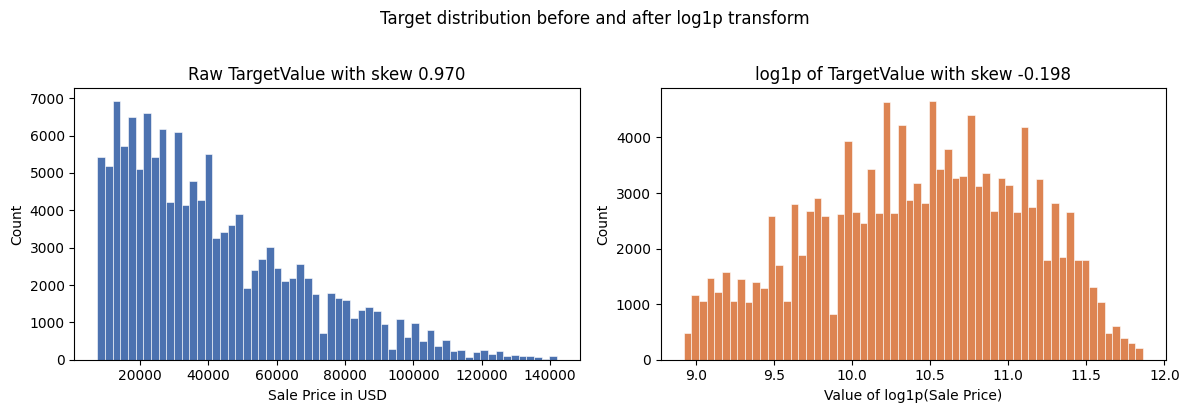

Minimum: 7,500, Median: 35,000, Maximum: 142,000
Raw Skew: 0.970, Log1p Skew: -0.198


In [8]:
#eda1 - raw vs log1p histogram
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
y = train["TargetValue"]
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].hist(y, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.4)
ax[0].set(title=f"Raw TargetValue with skew {y.skew():.3f}", xlabel="Sale Price in USD", ylabel="Count")

ax[1].hist(np.log1p(y), bins=60, color="#DD8452", edgecolor="white", linewidth=0.4)
ax[1].set(title=f"log1p of TargetValue with skew {np.log1p(y).skew():.3f}", xlabel="Value of log1p(Sale Price)", ylabel="Count")

plt.suptitle("Target distribution before and after log1p transform", y=1.02)
plt.tight_layout()
plt.show()

print(f"Minimum: {y.min():,.0f}, Median: {y.median():,.0f}, Maximum: {y.max():,.0f}")
print(f"Raw Skew: {y.skew():.3f}, Log1p Skew: {np.log1p(y).skew():.3f}")

# EDA-2 (Missing Data Analysis Column-wise)

The plot compares columns ranked by missing values percentage using severity based colour coding with a 80% reference line. 

The code isolates coumns with >99.5% data missing. Hence, 2 columns - col18, col19 has all its values missing, hence dropped.

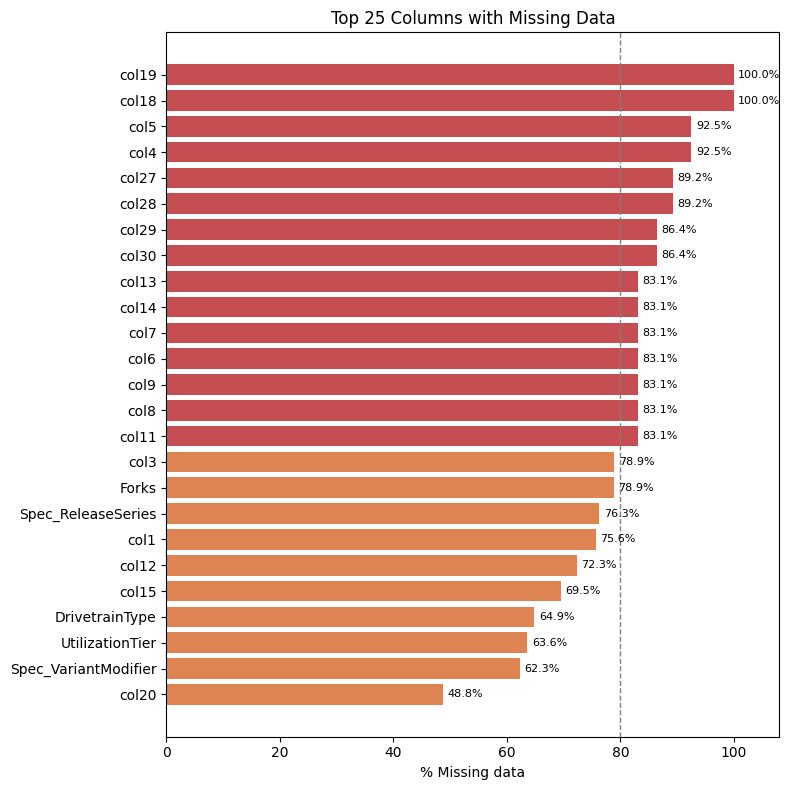

Empty Columns (hence dropped):
col19    66
col18    66


In [9]:
#eda2 - missing data percentage per column
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
y = train["TargetValue"]
miss = (train.isna().mean() * 100).sort_values(ascending=False)
top = miss[miss > 0].head(25)

colors = ["#C44E52" if v > 80 else "#DD8452" if v > 40 else "#4C72B0" for v in top.values[::-1]]

plt.figure(figsize=(8, 8))
plt.barh(top.index[::-1], top.values[::-1], color=colors)
for i, v in enumerate(top.values[::-1]):
    plt.text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=8)
plt.axvline(80, color="grey", ls="--", lw=1)
plt.xlim(0, 108)
plt.title("Top 25 Columns with Missing Data")
plt.xlabel("% Missing data")
plt.tight_layout()
plt.show()

near_empty = miss[miss > 99.5].index.tolist()
print(f"Empty Columns (hence dropped):")
print(train[near_empty].notna().sum().to_string())

# EDA-3 (Correlation of Missing Data)

The correlation heatmap shows how well a column is correlated to another column when a value goes missing in that column in a binary indicator

Columns with identical missing rates, marked by correlation of 1 which means loss of data together, have been identified by the code.

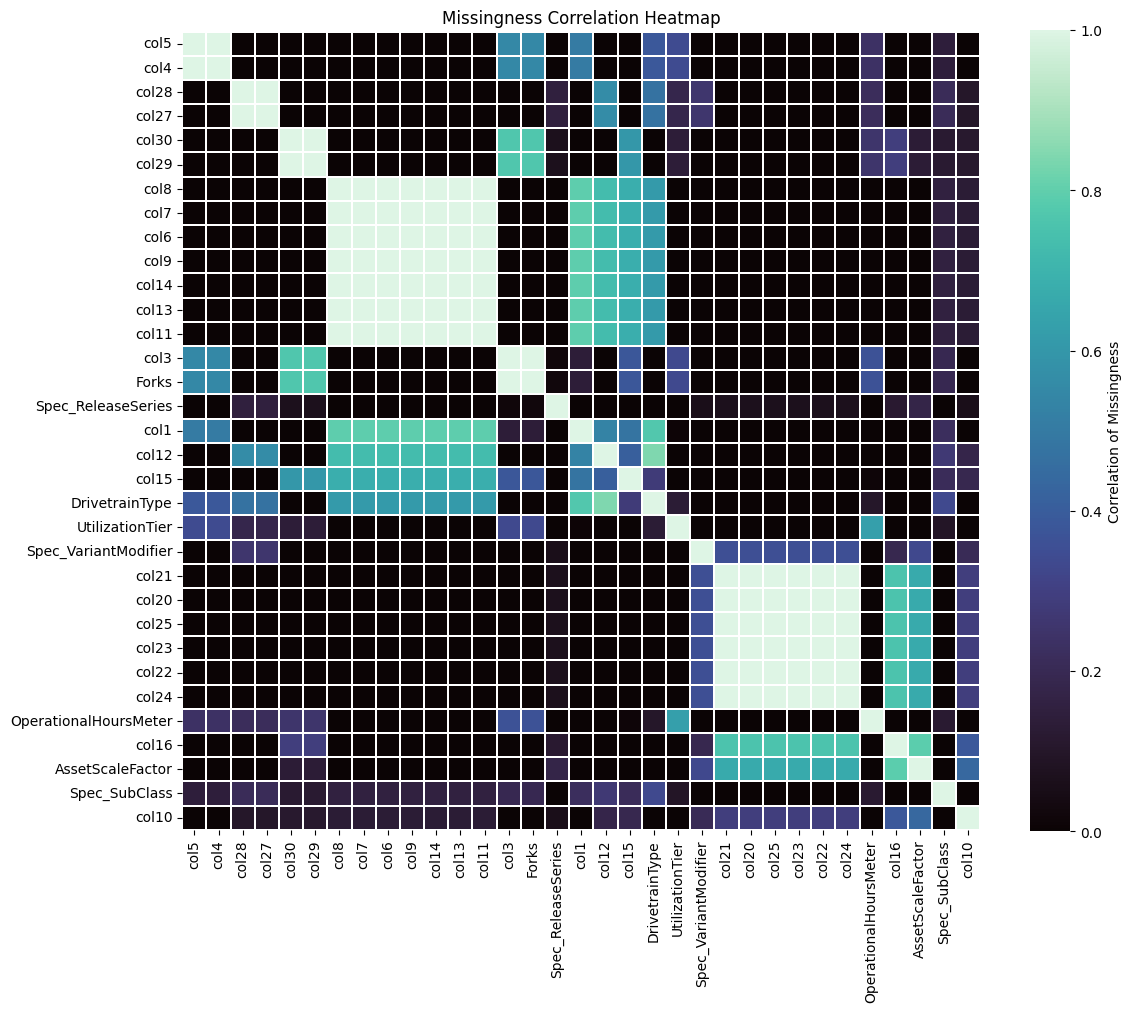

Blocks of columns with identical missing rate:
   48.8% : ['col21', 'col20', 'col25', 'col23', 'col22', 'col24']
   78.9% : ['col3', 'Forks']
   83.1% : ['col8', 'col7', 'col6', 'col9', 'col14', 'col13', 'col11']
   86.4% : ['col30', 'col29']
   89.2% : ['col28', 'col27']
   92.5% : ['col5', 'col4']


In [10]:
#eda3 - heatmap for missing values relation
rate = train.isna().mean()
mid = rate[(rate > 0.01) & (rate < 0.995)].sort_values(ascending=False).index

corr = train[mid].isna().astype(int).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="mako", vmin=0, vmax=1, square=True, linewidths=0.3, cbar_kws={"label": "Correlation of Missingness"})
plt.title("Missingness Correlation Heatmap")
plt.tight_layout()
plt.show()

blocks = (rate[mid].mul(100).round(1)
          .reset_index().groupby(0)["index"].apply(list))
blocks = blocks[blocks.apply(len) > 1]
print("Blocks of columns with identical missing rate:")
for r, cols in blocks.items():
    print(f"  {r:5.1f}% : {cols}")

# EDA-4 (Machine Sales per Year vs Median Sale Price)

The left plot visualizes number of machines (in semi-log scale) sold in each year for train and test dataset. The right plot shows median sales value for each year for train dataset.

This shows how the data is split, where if the test set had a later time period, a random validation split from that period would overstate performance and a chronological split would be needed then. Test share mean is 9.7%, with an 0.873pp standard deviation showing that split is random and validating from it is fine.

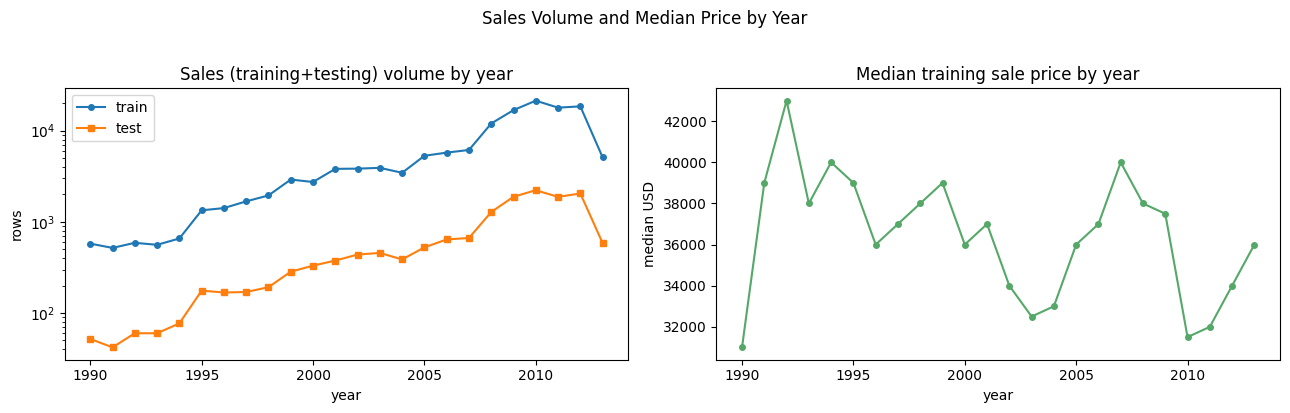


Test share of rows per year for last 10 years:
TransactionDate
2004    10.1
2005     9.0
2006    10.0
2007     9.8
2008     9.7
2009    10.1
2010     9.4
2011     9.5
2012    10.0
2013    10.3

Mean: 9.704%, Std Dev: 0.873pp


In [11]:
#eda4 - median and sales per year
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])
test["TransactionDate"] = pd.to_datetime(test["TransactionDate"])

tr_yr = train["TransactionDate"].dt.year.value_counts().sort_index()
te_yr = test["TransactionDate"].dt.year.value_counts().sort_index()
med   = train.groupby(train["TransactionDate"].dt.year)["TargetValue"].median()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(tr_yr.index, tr_yr.values, marker="o", ms=4, label="train")
ax[0].plot(te_yr.index, te_yr.values, marker="s", ms=4, label="test")
ax[0].set(title="Sales (training+testing) volume by year", xlabel="year", ylabel="rows")
ax[0].set_yscale("log")
ax[0].legend()

ax[1].plot(med.index, med.values, marker="o", ms=4, color="#55A868")
ax[1].set(title="Median training sale price by year", xlabel="year", ylabel="median USD")

plt.suptitle("Sales Volume and Median Price by Year", y=1.02)
plt.tight_layout()
plt.show()

share = (te_yr / (te_yr + tr_yr) * 100).round(1)
print(f"\nTest share of rows per year for last 10 years:\n{share.tail(10).to_string()}")
print(f"\nMean: {share.mean():.3f}%, Std Dev: {share.std():.3f}pp")

# EDA-5 (Price drop with Machine age)

The plot visualizes age as sale year - manufacture year in comparison with mean log1p price. Year > 1900 is used to handle missing values and absurd ages. 

Ages are grouped into bins and mean log price per bin is made with 95% confidence intervals. Error bars widen at high ages where fewer machines are there. There is a negative correlation between price and age, and mean log1p price also drops gradually showing depreciation.

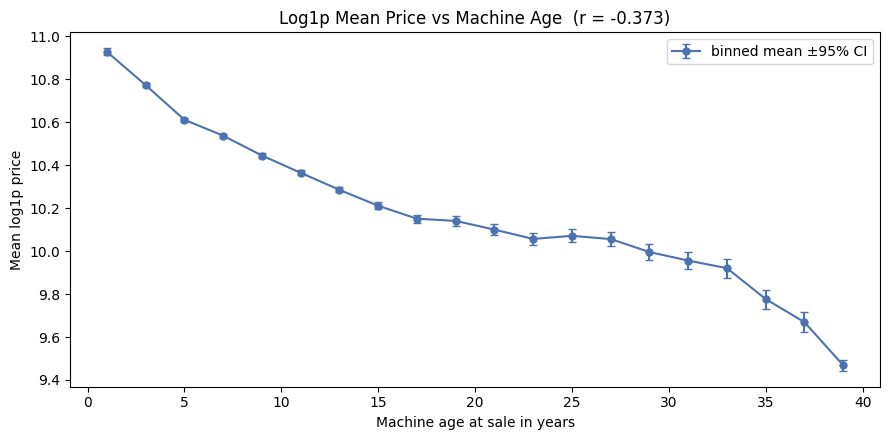


Correlation (age, log price) = -0.373
            mean    sem   size
(0, 2]    10.927  0.008   5438
(2, 4]    10.772  0.004  20132
(4, 6]    10.611  0.004  23891
(6, 8]    10.537  0.005  17558
(8, 10]   10.445  0.005  13212
(10, 12]  10.364  0.006  10971
(12, 14]  10.285  0.006   8888
(14, 16]  10.211  0.008   5486
(16, 18]  10.151  0.010   3895
(18, 20]  10.140  0.012   2823
(20, 22]  10.100  0.013   2395
(22, 24]  10.057  0.014   1936
(24, 26]  10.071  0.016   1521
(26, 28]  10.056  0.017   1319
(28, 30]   9.996  0.018   1140
(30, 32]   9.956  0.020    908
(32, 34]   9.920  0.023    700
(34, 36]   9.777  0.023    491
(36, 38]   9.669  0.024    375
(38, 40]   9.469  0.013    787


In [12]:
#eda5 - price vs machine age
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])
yr = train["ManufactureYear"]

age = train["TransactionDate"].dt.year - yr.where(yr > 1900)
logp = np.log1p(train["TargetValue"])

bins = pd.cut(age.clip(0, 40), bins=range(0, 42, 2))
grp = logp.groupby(bins, observed=True).agg(["mean", "sem", "size"])
centres = [iv.mid for iv in grp.index]

plt.figure(figsize=(9, 4.5))
plt.errorbar(centres, grp["mean"], yerr=grp["sem"] * 1.96, marker="o", ms=5, capsize=3, color="#4C72B0", label="binned mean ±95% CI")
plt.title(f"Log1p Mean Price vs Machine Age  (r = {age.corr(logp):.3f})")
plt.xlabel("Machine age at sale in years")
plt.ylabel("Mean log1p price")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nCorrelation (age, log price) = {age.corr(logp):.3f}")
print(grp.round(3).to_string())

# EDA-6 (Simpson's Paradox - Machine Usage vs Correlation of machine hours and log1p price)

The plot visualizes machine usage classes with respect to correlation of machine hours and log1p price.

The correlation is done with pooled and within class, where pooled shows more machine hours mean higher price, but within class comparison shows more machine hours mean lower price, showing a reversal, a Simpson's paradox.

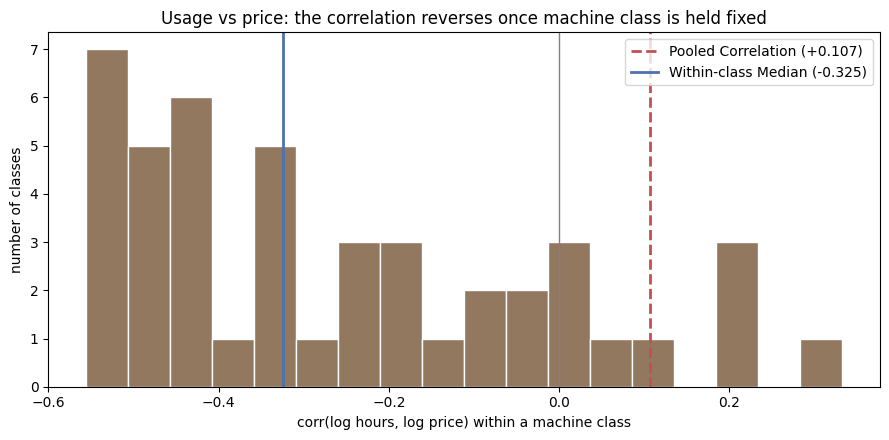

Share of Classes Negative   : 82%
Within-class IQR            : -0.459 to -0.076


In [13]:
#eda6 - simpson's paradox
pooled = np.log1p(train["OperationalHoursMeter"].replace(0, np.nan)).corr(np.log1p(train["TargetValue"]))


probe = pd.DataFrame( {
        "cls": train["FunctionalClassification"],
        "logh": np.log1p(train["OperationalHoursMeter"].replace(0, np.nan)),
        "logp": np.log1p(train["TargetValue"]),
    }
).dropna()

big = probe.groupby("cls", observed=True).filter(lambda g: len(g) >= 200)
within = (big.groupby("cls", observed=True).apply(lambda g: g["logh"].corr(g["logp"]), include_groups=False).dropna())

plt.figure(figsize=(9, 4.5))
plt.hist(within, bins=18, color="#937860", edgecolor="white")
plt.axvline(pooled, color="#C44E52", ls="--", lw=2, label=f"Pooled Correlation ({pooled:+.3f})")
plt.axvline(within.median(), color="#4C72B0", ls="-", lw=2, label=f"Within-class Median ({within.median():+.3f})")
plt.axvline(0, color="grey", lw=1)
plt.title("Usage vs price: the correlation reverses once machine class is held fixed")
plt.xlabel("corr(log hours, log price) within a machine class")
plt.ylabel("number of classes")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Share of Classes Negative   : {(within < 0).mean():.0%}")
print(f"Within-class IQR            : {within.quantile(.25):+.3f} to {within.quantile(.75):+.3f}")

# EDA-7 (Price vs Machine Size with quartile denotion)

The plot is a boxplot where minimum, maximum, interquartile ranges, median values of log1p price compared with machine size (AssetScaleFactor) are represented in a single plot.

Median prices rise as categories go up chronologically. It is identified that 29.7% of row data is missing and hence imputation is required for this.

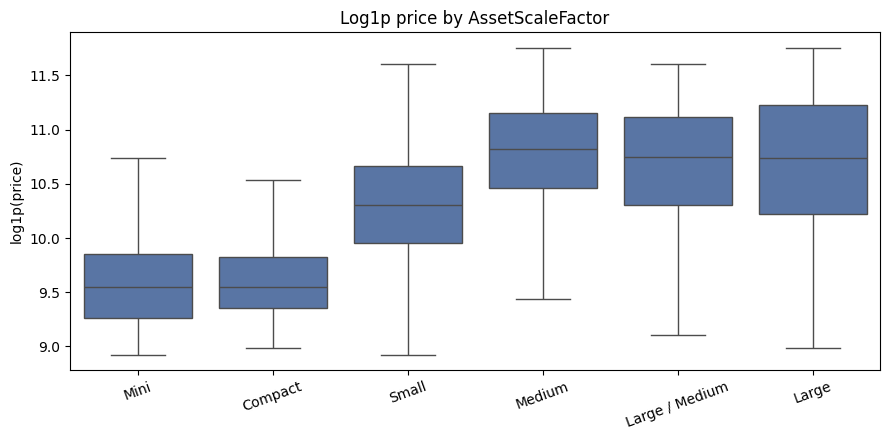

                   median   size
AssetScaleFactor                
Mini              14000.0  13663
Compact           14000.0   1794
Small             30000.0  18119
Medium            50000.0  21918
Large / Medium    46500.0  39222
Large             46000.0   2775

AssetScaleFactor missing: 29.7%


In [14]:
#eda7 - price by asset scale
Sc = ["Mini", "Compact", "Small", "Medium", "Large / Medium", "Large"]
sco = [s for s in Sc if s in set(train["AssetScaleFactor"].dropna())]

plt.figure(figsize=(9, 4.5))
sns.boxplot(data=train, x="AssetScaleFactor", y=np.log1p(train["TargetValue"]), order=sco, showfliers=False, color="#4C72B0")
plt.title("Log1p price by AssetScaleFactor")
plt.xlabel("")
plt.ylabel("log1p(price)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(train.groupby("AssetScaleFactor", observed=True)["TargetValue"].agg(["median", "size"]).reindex(sco).to_string())
print(f"\nAssetScaleFactor missing: {train['AssetScaleFactor'].isna().mean():.1%}")

# EDA-8 (Price vs Machine Family with quartile denotion)

The plot is a boxplot where minimum, maximum, interquartile ranges, median values of log1p price compared with machine family are represented in a single plot.

Sorting this graph by the plotted values' median log1p prices makes ranking visualizable.

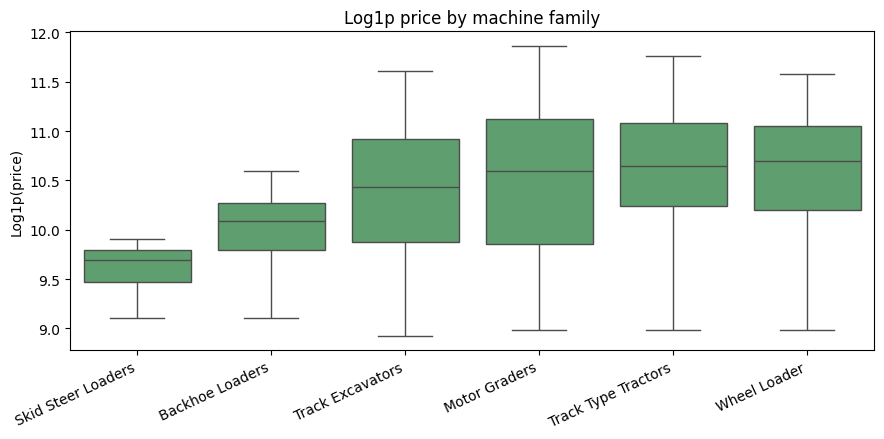

                            median   size
InventoryGroupDescription                
Skid Steer Loaders         16250.0     66
Backhoe Loaders            24000.0  10381
Track Excavators           34000.0  71018
Motor Graders              40000.0  23405
Track Type Tractors        42000.0  14959
Wheel Loader               44000.0  18872


In [15]:
#eda8 - price by machine family
fam_order = (train.groupby("InventoryGroupDescription", observed=True)["TargetValue"].median().sort_values().index)

plt.figure(figsize=(9, 4.5))
sns.boxplot(data=train, x="InventoryGroupDescription", y=np.log1p(train["TargetValue"]), order=fam_order, showfliers=False, color="#55A868")
plt.title("Log1p price by machine family")
plt.xlabel("")
plt.ylabel("Log1p(price)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print(train.groupby("InventoryGroupDescription", observed=True)["TargetValue"].agg(["median", "size"]).sort_values("median").to_string())

# EDA-9 (Repeat sale occurrences of same machines)

The left plot compares AssetID with sale frequency as AssetID identifies a machine and one machine can be sold multiple times in semi-log scale. The right plot compares machines (in normal sacle) with log1p price's standard deviation.

This identifies number of unique machines out of total rows and number of repeat sales, with 2 standard deviations, one of the whole market's log1p price and the other, median of the spread inside one machine.

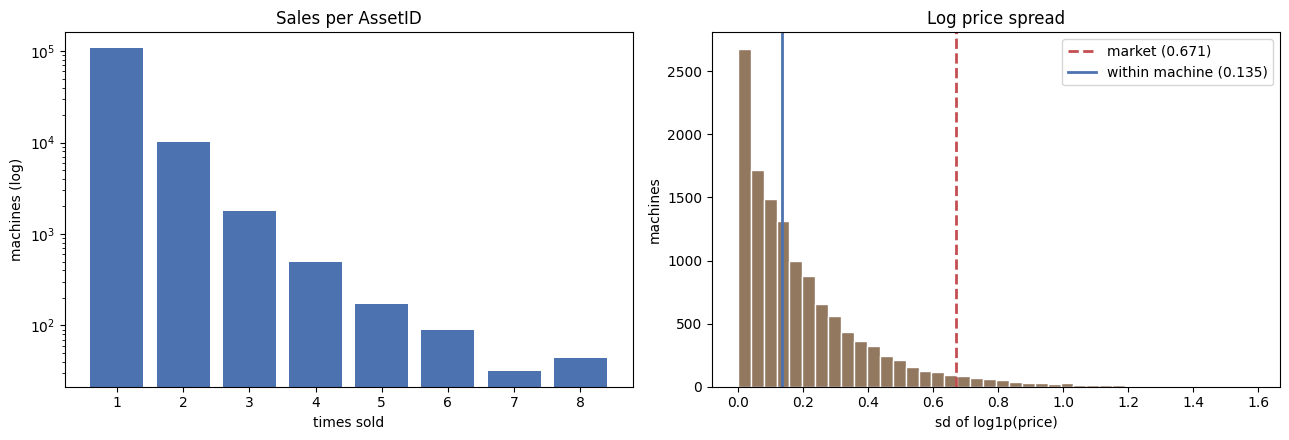

Unique machines      : 120,111 / 138,701 rows
Repeat-sale rows     : 31,447
Test rows already priced in train: 23.3%
Log price variance left once AssetID known: 4.1%


In [16]:
#eda9 - repeat sales of the same physical machine
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

cnt = train["AssetID"].value_counts()
rep = train[train["AssetID"].map(cnt) > 1].copy()
rep["logp"] = np.log1p(rep["TargetValue"])
within = rep.groupby("AssetID")["logp"].std().dropna()
overall = np.log1p(train["TargetValue"]).std()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

times = cnt.value_counts().sort_index()
ax[0].bar(times.index[:8], times.values[:8], color="#4C72B0")
ax[0].set_yscale("log")
ax[0].set(title="Sales per AssetID", xlabel="times sold", ylabel="machines (log)")

ax[1].hist(within, bins=40, color="#937860", edgecolor="white")
ax[1].axvline(overall, color="#C44E52", ls="--", lw=2, label=f"market ({overall:.3f})")
ax[1].axvline(within.median(), color="#4C72B0", lw=2, label=f"within machine ({within.median():.3f})")
ax[1].set(title="Log price spread", xlabel="sd of log1p(price)", ylabel="machines")
ax[1].legend()

plt.tight_layout()
plt.show()

shared = set(train["AssetID"]) & set(test["AssetID"])
print(f"Unique machines      : {train['AssetID'].nunique():,} / {len(train):,} rows")
print(f"Repeat-sale rows     : {(train['AssetID'].map(cnt) > 1).sum():,}")
print(f"Test rows already priced in train: {test['AssetID'].isin(shared).mean():.1%}")
print(f"Log price variance left once AssetID known: {(within.median() / overall) ** 2:.1%}")

# EDA-10 (Price as a discrete commodity)

The left plot shows how many prices are exact multiples of 50, 100, 500, 1000 (denoting exact round values) with percentage of rows, where right one shows the same but comparing with count instead.

As seen, there are only 675 distinct prices across all rows, as discrete components rather than a continuous one.

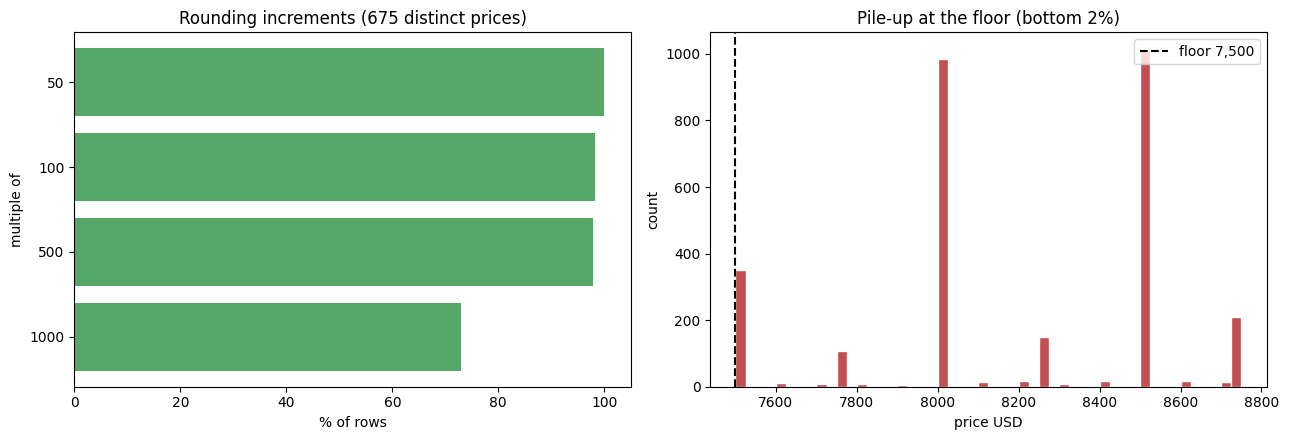

Distinct prices : 675 / 138,701 rows
Range           : 7,500 to 142,000
On the floor    : 350 rows
On the ceiling  : 5 rows


In [17]:
#eda10 - the target is rounded and bounded, not continuous
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

y = train["TargetValue"]

incr = pd.Series({"1000": (y % 1000 == 0).mean(), "500": (y % 500 == 0).mean(), "100": (y % 100 == 0).mean(), "50": (y % 50 == 0).mean()}) * 100
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].barh(incr.index, incr.values, color="#55A868")
ax[0].set_xlim(0, 105)
ax[0].set(title=f"Rounding increments ({y.nunique()} distinct prices)", xlabel="% of rows", ylabel="multiple of")

low = y[y <= y.quantile(0.02)]
ax[1].hist(low, bins=50, color="#C44E52", edgecolor="white")
ax[1].axvline(y.min(), color="black", ls="--", lw=1.5, label=f"floor {y.min():,.0f}")
ax[1].set(title="Pile-up at the floor (bottom 2%)", xlabel="price USD", ylabel="count")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Distinct prices : {y.nunique()} / {len(y):,} rows")
print(f"Range           : {y.min():,.0f} to {y.max():,.0f}")
print(f"On the floor    : {(y == y.min()).sum()} rows")
print(f"On the ceiling  : {(y == y.max()).sum()} rows")

# EDA-11 (Categorical cardinality and how they are unseen in testing)

The left plot shows how many distinct level are there for each feature in training set in semi-log scale. The right plot shows what share of test rows carry levels not seen in training.

The high cardinality suggests that one-hot encoder is not a good option to encode here as it would expand itno many mostly-zero columns.

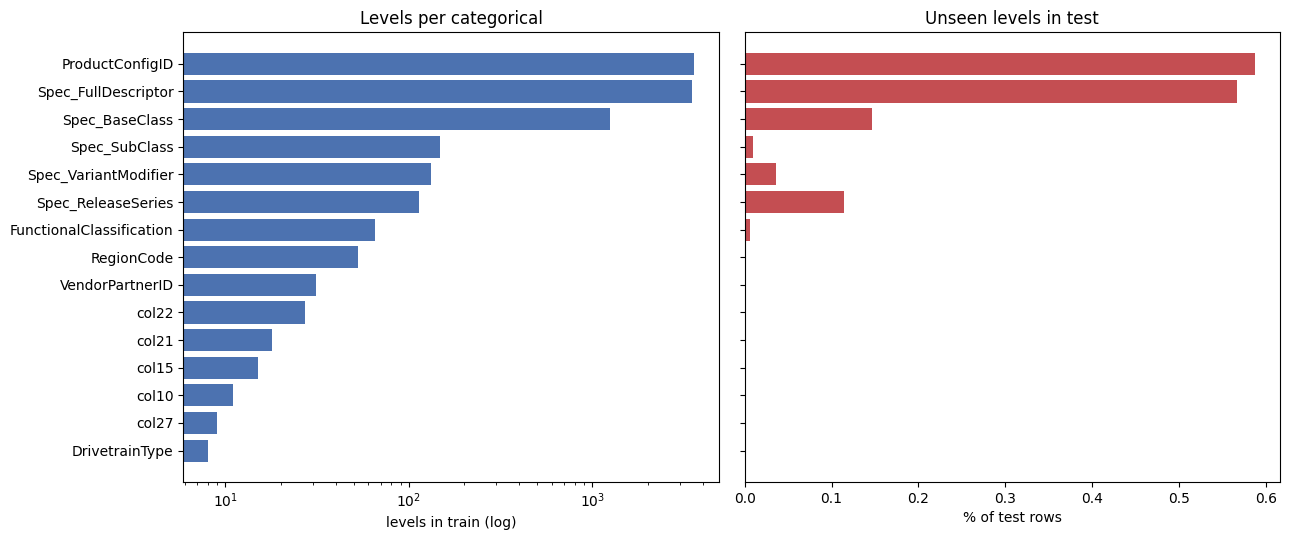

                 col  levels  unseen_%
     ProductConfigID    3594      0.59
 Spec_FullDescriptor    3505      0.57
      Spec_BaseClass    1249      0.15
  Spec_ReleaseSeries     113      0.11
Spec_VariantModifier     132      0.04
       Spec_SubClass     147      0.01


In [18]:
#eda11 - categorical cardinality and unseen levels at predict time
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

cats = [c for c in test.columns if str(test[c].dtype) not in ("int64", "float64")] + ["ProductConfigID"]
cats = [c for c in cats if c != "TransactionDate"]

rec = []
for c in cats:
    seen = set(train[c].dropna().unique())
    m = test[c].notna()
    unseen = (~test.loc[m, c].isin(seen)).mean() * 100 if m.sum() else 0.0
    rec.append((c, train[c].nunique(), unseen))

d = pd.DataFrame(rec, columns=["col", "levels", "unseen"]).sort_values("levels", ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

ax[0].barh(d["col"], d["levels"], color="#4C72B0")
ax[0].set_xscale("log")
ax[0].set(title="Levels per categorical", xlabel="levels in train (log)")

ax[1].barh(d["col"], d["unseen"], color="#C44E52")
ax[1].set(title="Unseen levels in test", xlabel="% of test rows")

plt.tight_layout()
plt.show()

print(pd.DataFrame(rec, columns=["col", "levels", "unseen_%"]).sort_values("unseen_%", ascending=False).head(6).round(2).to_string(index=False))

# EDA-12 (Relating how engineered date affects the prediction)

The left plot shows how median sales price varies with each month of the year. The right plot shows how median sales price varies with each day of the week, with a line showing the sales volume of each day.

The volume depiction exposes the trap of having no difference bwetween a low volume sale of high priced machine and a high volume sale of low priced machine.

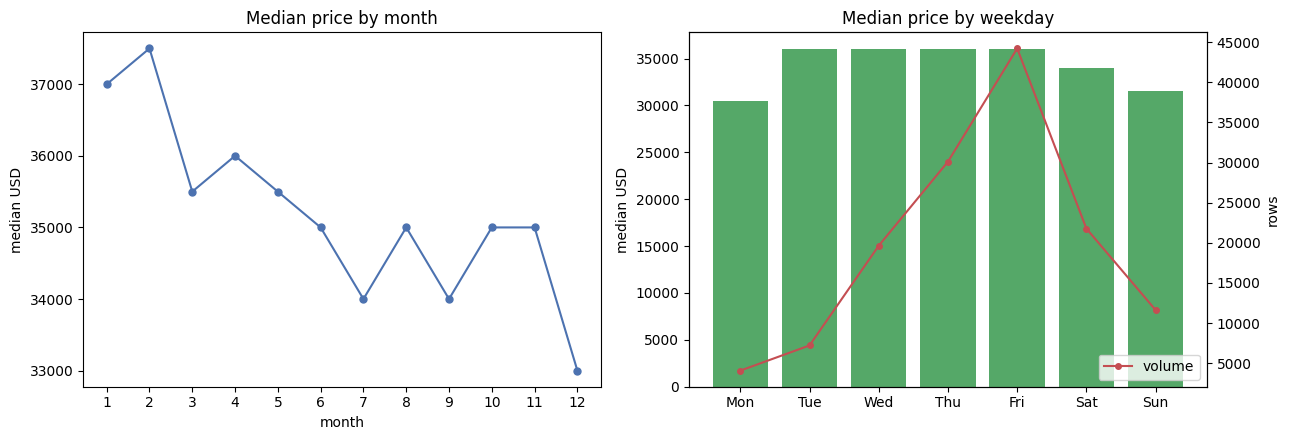

Month spread   : 33,000 to 37,500  (13.6%)
Weekday spread : 30,500 to 36,000  (18.0%)
Sales on Wed-Fri: 67.8%


In [19]:
#eda12 - do the engineered date features carry signal?
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

d = pd.to_datetime(train["TransactionDate"])
y = train["TargetValue"]

mn = y.groupby(d.dt.month).median()
dw = y.groupby(d.dt.dayofweek).median()
vol = d.dt.dayofweek.value_counts().sort_index()
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(mn.index, mn.values, marker="o", ms=5, color="#4C72B0")
ax[0].set(title="Median price by month", xlabel="month", ylabel="median USD")
ax[0].set_xticks(range(1, 13))

ax[1].bar(days, dw.values, color="#55A868")
ax[1].set(title="Median price by weekday", ylabel="median USD")
ax2 = ax[1].twinx()
ax2.plot(days, vol.values, marker="o", ms=4, color="#C44E52", label="volume")
ax2.set_ylabel("rows")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Month spread   : {mn.min():,.0f} to {mn.max():,.0f}  ({(mn.max()/mn.min()-1)*100:.1f}%)")
print(f"Weekday spread : {dw.min():,.0f} to {dw.max():,.0f}  ({(dw.max()/dw.min()-1)*100:.1f}%)")
print(f"Sales on Wed-Fri: {vol[[2,3,4]].sum()/vol.sum():.1%}")

---------------------------------------------------------

# ***Preprocessing:***

# Feature Engineering

* Raw tables are converted to modellig matrices. First, train and test datasets are concatenated to apply transformations on the whole dataset, later split up again for further processes.
* Target is log1p transformed TargetValue.
* Date features engineered to have programmable seaparate features for sale year, sale month, sale weekday, sale day of the year and day count since 1990-01-01 (for reference), with absurd dates and missing values made NaN. Hence, TransactionDate is dropped.
* TransactionID is dropped as it has no predictive value for the process.
* 0s in operational hours have been noticed, and made into NaN as well.
* New columns made are age (sale year - manufacture year, clipped at 0 to 60) and log_hrs (log1p(OperationalHoursMeter)).
* ProductConfigID is made as string before categorical conversion, else if it is a number, it will be treated as a quantity.
* All features with string and object datatypes have been converted into category to define splits used by models.
* prc_l and prc_h are the TargetValue's floor and ceil values.

In [8]:
#preprocess
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore") 

train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')
n_tr = len(train)

X = pd.concat([train.drop(columns=["TargetValue"]), test], ignore_index = True)
y = np.log1p(train["TargetValue"])
test_ids = test["TransactionID"]
prc_l = train["TargetValue"].min()
prc_h = train["TargetValue"].max()

X["TransactionDate"] = pd.to_datetime(X["TransactionDate"])
X["sl_yr"] = X["TransactionDate"].dt.year
X["sl_mn"] = X["TransactionDate"].dt.month
X["sl_dw"] = X["TransactionDate"].dt.dayofweek
X["sl_dy"] = X["TransactionDate"].dt.dayofyear
X["sl_days"] = (X["TransactionDate"] - pd.Timestamp("1990-01-01")).dt.days
X["ManufactureYear"] = X["ManufactureYear"].where(X["ManufactureYear"] > 1900)
X["OperationalHoursMeter"] = X["OperationalHoursMeter"].replace(0, np.nan)
X["age"] = (X["sl_yr"] - X["ManufactureYear"]).clip(0, 60)
X["log_hrs"] = np.log1p(X["OperationalHoursMeter"])
X["ProductConfigID"] = X["ProductConfigID"].astype(str)

X = X.drop(columns = ["TransactionDate", "TransactionID"])
for c in X.select_dtypes(include=["object", "string"]).columns:
    X[c] = X[c].astype("category")

Xtr, Xte = X.iloc[:n_tr], X.iloc[n_tr:]
print(Xtr.shape, Xte.shape)

(138701, 54) (15000, 54)


# Importing required dependencies for all machine learning model operations

In [6]:
#ml imports
import numpy as np
import pandas as pd
import time
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_log_error as rmsle
from scipy.stats import randint, uniform

# ***Machine Learning Model Implementation:***
5 Models have been implemented and tested:

* Decision Tree Regressor
* HistGradientBoosting Regressor
* LightGBM Regressor
* CatBoost Regressor
* XGBoost Regressor

All models will be evaluated and an ensemble will be chosen with respect to their performances.

# Decision Tree Regressor
This is a simple regression tree that can capture non-linear relationships and feature correlations.

Hyperparameter Tuning is done with RandomizedSearchCV to obtain the best hyperparameters to train and test on.

In [ ]:
#mdl1 - decision tree regressor (tree model) (finding best hyperparameters)
X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

dtr = DecisionTreeRegressor(
    random_state=42
)

para1 = {
    "max_depth": [5, 10, 15, 20, 30, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}

grid1 = RandomizedSearchCV(
    estimator=dtr,
    param_distributions=para1,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

grid1.fit(X_tr, y_tr)

best = grid1.best_estimator_

tr_pd = np.expm1(best.predict(X_tr))
vd_pd = np.expm1(best.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle1 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle1, 5))

vd_rmsle1 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle1, 5))

print("\nAt parameters")
print(grid1.best_params_)

### Best hyperparameters of Decision Tree Regressor are - **max_depth=15, min_samples_split=2, min_samples_leaf=1, random_state=42**

# Decision Tree Regressor with best hyperparameters

In [23]:
#mdl1 - decision tree regressor (tree model) withbest hyperparameters
X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

best = DecisionTreeRegressor(
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

print("Starting DTR")

start = time.time()

best.fit(X_tr, y_tr)
elapsed = time.time() - start

print(f"DTR completed in {elapsed:.2f} seconds")

tr_pd = np.expm1(best.predict(X_tr))
vd_pd = np.expm1(best.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle1 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle1, 5))

vd_rmsle1 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle1, 5))

Starting DTR
DTR completed in 2.30 seconds
Training RMSLE:
0.24115

Validation RMSLE:
0.2913


## Results:
### * Training RMSLE = 0.24115
### * Validation RMSLE = 0.2913
### * Training RMSLE = 0.05015

# HistGradientBoosting

This builds trees sequentially, correcting each of the residual errors above it in histogram-based variant bins.

Hyperparameter Tuning is done with RandomizedSearchCV to obtain the best hyperparameters to train and test on.

In [ ]:
#mdl2 - histogram gradient boosting regressor (ensemble model) (finding best hyperparameters)
X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                                       unknown_value=-1))
        ]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

hgb = HistGradientBoostingRegressor(random_state=42)

para5 = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_iter": [100, 200, 300],
    "max_leaf_nodes": [15, 31, 63],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [20, 30, 50],
    "l2_regularization": [0, 0.1, 1]
}

grid5 = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=para5,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

grid5.fit(X_tr, y_tr)

best = grid5.best_estimator_

tr_pd = np.expm1(best.predict(X_tr))
vd_pd = np.expm1(best.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle5 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle5, 5))

vd_rmsle5 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle5, 5))

print("\nAt parameters")
print(grid5.best_params_)

### Best hyperparameters of HistGradientBoosting Regressor are - **learning_rate=0.05, max_iter=700, max_leaf_nodes=127, max_depth=10, min_samples_leaf=10, l2_regularization=0.1, random_state=42**

# HistGradientBoostingRegressor with best hyperparameters

In [24]:
#mdl2 - histogram gradient boosting regressor (ensemble model) with best hyperparameters
X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=700,
    max_leaf_nodes=127,
    max_depth=10,
    min_samples_leaf=10,
    l2_regularization=0.1,
    random_state=42
)

print("Starting HGB")

start = time.time()

hgb_model.fit(X_tr, y_tr)
elapsed = time.time() - start

print(f"HGB completed in {elapsed:.2f} seconds")

tr_pd = np.expm1(hgb_model.predict(X_tr))
vd_pd = np.expm1(hgb_model.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle4 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle4, 5))

vd_rmsle4 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle4, 5))

hgb_pred = np.expm1(hgb_model.predict(X_ts))

Starting HGB
HGB completed in 26.88 seconds
Training RMSLE:
0.17363

Validation RMSLE:
0.21549


## Results:
### * Training RMSLE = 0.17363
### * Validation RMSLE = 0.21549
### * Gap = +0.04186

# LightGBM Regressor

This grows trees leaf-wise rather than level-wise where each step leaves are split to get largest loss reduction. This gives more selective trees for same number of nodes.

Hyperparameter Tuning is done with RandomizedSearchCV to obtain the best hyperparameters to train and test on.

In [ ]:
#mdl3 - light gradient boosting machine regressor (lightgbm model) (finding best hyperparameters)
X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                                       unknown_value=-1))
        ]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

lgb = LGBMRegressor(random_state=42, verbosity=-1)

para5 = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 10, 20],
    "min_child_samples": [10, 20, 50],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

grid5 = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=para5,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

grid5.fit(X_tr, y_tr)

best = grid5.best_estimator_

tr_pd = np.expm1(best.predict(X_tr))
vd_pd = np.expm1(best.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle5 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle5, 5))

vd_rmsle5 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle5, 5))

print("\nAt parameters")
print(grid5.best_params_)

### Best hyperparameters of LightGBM Regressor are - **subsample=0.9, reg_lambda=5, reg_alpha=0.1, num_leaves=350, n_estimators=2500, min_child_samples=8, max_depth=10, learning_rate=0.05, colsample_bytree=0.6, random_state=42, verbosity=0**

# LightGBM Regressor with best hyperparameters

In [25]:
#mdl3 - light gradient boosting machine regressor (lightgbm model) with best hyperparameters
import warnings
warnings.filterwarnings("ignore") 

X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

lgbm_model = LGBMRegressor(
    subsample=0.9,
    reg_lambda=5,
    reg_alpha=0.1,
    num_leaves=350,
    n_estimators=2500,
    min_child_samples=8,
    max_depth=10,
    learning_rate=0.05,
    colsample_bytree=0.6,
    random_state=42,
    verbosity=0
)

print("Starting LGBM")

start = time.time()

lgbm_model.fit(X_tr, y_tr)
elapsed = time.time() - start

print(f"LGBM completed in {elapsed:.2f} seconds")

tr_pd = np.expm1(lgbm_model.predict(X_tr))
vd_pd = np.expm1(lgbm_model.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle5 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle5, 5))

vd_rmsle5 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle5, 5))

Starting LGBM
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

## Results:
### * Training RMSLE = 0.08337
### * Validation RMSLE = 0.20076
### * Gap = +0.11739

# CatBoost Regressor

This uses ordered boosting implementing permutations to avoid data leakage that affects standard gradient boosting techniques and mainly used in categorical-based datasets.

Hyperparameter Tuning is done with RandomizedSearchCV to obtain the best hyperparameters to train and test on.

In [ ]:
#mdl4 - categorical boosting (catboost model) (finding best hyperparameters)
X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                                       unknown_value=-1))
        ]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

cat = CatBoostRegressor(
    random_state=42,
    verbose=0
)

para6 = {
    "iterations": [300, 500, 700],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.8, 0.9, 1.0]
}

grid6 = RandomizedSearchCV(
    estimator=cat,
    param_distributions=para6,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

grid6.fit(X_tr, y_tr)

best = grid6.best_estimator_

tr_pd = np.expm1(best.predict(X_tr))
vd_pd = np.expm1(best.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle6 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle6, 5))

vd_rmsle6 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle6, 5))

print("\nAt parameters")
print(grid6.best_params_)

### Best hyperparameters of CatBoost Regressor are - **iterations=1500, learning_rate=0.1, depth=12, l2_leaf_reg=3, subsample=1.0, random_seed=42, verbose=0**

# CatBoost Regressor with best hyperparameters

In [26]:
#mdl4 - categorical boosting (catboost model) with best hyperparameters
X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

best = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.1,
    depth=12,
    l2_leaf_reg=3,
    subsample=1.0,
    random_seed=42,
    verbose=0
)

print("Starting CB")

start = time.time()

best.fit(X_tr, y_tr)
elapsed = time.time() - start

print(f"CB completed in {elapsed:.2f} seconds")

tr_pd = np.expm1(best.predict(X_tr))
vd_pd = np.expm1(best.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle6 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle6, 5))

vd_rmsle6 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle6, 5))

Starting CB
CB completed in 168.19 seconds
Training RMSLE:
0.20952

Validation RMSLE:
0.2916


## Results:
### * Training RMSLE = 0.20952
### * Validation RMSLE = 0.2916
### * Gap = +0.08208

# XGBoost Regressor

This model grows trees level-wise where each node is expanded at that depth before going to next with a balanced workflow and robust to overfitting.

Hyperparameter Tuning is done with RandomizedSearchCV to obtain the best hyperparameters to train and test on.

In [ ]:
#mdl5 - extreme gradient boosting regressor (xgboost model) (finding best hyperparameters)
X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

para5 = {
    "n_estimators": [1000, 1500, 2000],
    "learning_rate": [0.02, 0.03, 0.05],
    "max_depth": [6, 7, 8],
    "min_child_weight": [1, 2, 3],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.7, 0.8],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [5, 8, 10]
}

grid5 = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=para5,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

grid5.fit(X_tr, y_tr)

best = grid5.best_estimator_

tr_pd = np.expm1(best.predict(X_tr))
vd_pd = np.expm1(best.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle5 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle5, 5))

vd_rmsle5 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle5, 5))

print("\nAt parameters")
print(grid5.best_params_)

### Best hyperparameters of XGBoost Regressor are - **subsample=0.8, reg_lambda=8, reg_alpha=0.5, n_estimators=2000, min_child_weight=1, max_depth=8, learning_rate=0.03, colsample_bytree=0.7, objective="reg:squarederror", tree_method="hist", random_state=42, n_jobs=-1, verbose=0**

# XGBoost Regressor with best hyperparameters

In [27]:
#mdl5 - extreme gradient boosting regressor (xgboost model) with best hyperparameters
X_tr, X_vd, y_tr, y_vd = train_test_split(Xtr, y, test_size=0.2, random_state=42)

cat_cols = Xtr.select_dtypes(include="category").columns
num_cols = Xtr.select_dtypes(exclude="category").columns

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]), cat_cols)
    ]
)

X_tr = pre.fit_transform(X_tr)
X_vd = pre.transform(X_vd)
X_ts = pre.transform(Xte)

xgb_model = XGBRegressor(
    subsample=0.8,
    reg_lambda=8,
    reg_alpha=0.5,
    n_estimators=2000,
    min_child_weight=1,
    max_depth=8,
    learning_rate=0.03,
    colsample_bytree=0.7,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Starting XGB")

start = time.time()

xgb_model.fit(X_tr, y_tr)

elapsed = time.time() - start

print(f"XGB completed in {elapsed:.2f} seconds")

tr_pd = np.expm1(xgb_model.predict(X_tr))
vd_pd = np.expm1(xgb_model.predict(X_vd))

y_trx = np.expm1(y_tr)
y_vdx = np.expm1(y_vd)

tr_rmsle5 = rmsle(y_trx, tr_pd)
print("Training RMSLE:")
print(round(tr_rmsle5, 5))

vd_rmsle5 = rmsle(y_vdx, vd_pd)
print("\nValidation RMSLE:")
print(round(vd_rmsle5, 5))

xgb_pred = np.expm1(xgb_model.predict(X_ts))

Starting XGB
XGB completed in 29.44 seconds
Training RMSLE:
0.15328

Validation RMSLE:
0.20643


## Results:
### * Training RMSLE = 0.15328
### * Validation RMSLE = 0.20643
### * Gap = +0.05315

---------------------------------------------------------

# ***Model Comparison:***
### Comparing all 5 models to choose the best ensemble by training and validation RMSLE scores.

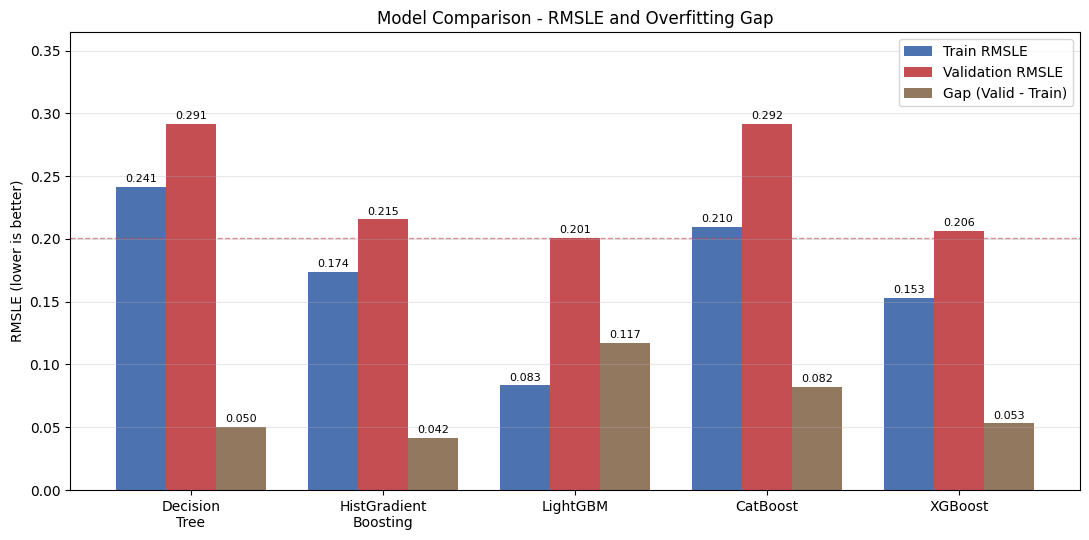

In [4]:
#comparison - train vs validation rmsle and overfitting gap
import numpy as np
import matplotlib.pyplot as plt

models = ["Decision\nTree", "HistGradient\nBoosting", "LightGBM", "CatBoost", "XGBoost"]
train_rmsle = [0.24115, 0.17363, 0.08337, 0.20952, 0.15328]
valid_rmsle = [0.29130, 0.21549, 0.20076, 0.29160, 0.20643]
gap = [v - t for v, t in zip(valid_rmsle, train_rmsle)]

x = np.arange(len(models))
w = 0.26

fig, ax = plt.subplots(figsize=(11, 5.5))
b1 = ax.bar(x - w, train_rmsle, w, label="Train RMSLE", color="#4C72B0")
b2 = ax.bar(x,     valid_rmsle, w, label="Validation RMSLE", color="#C44E52")
b3 = ax.bar(x + w, gap,         w, label="Gap (Valid - Train)", color="#937860")

for b in (b1, b2, b3):
    ax.bar_label(b, fmt="%.3f", fontsize=8, padding=2)

best = int(np.argmin(valid_rmsle))
ax.axhline(valid_rmsle[best], color="#C44E52", ls="--", lw=1, alpha=0.6)

ax.set(title="Model Comparison - RMSLE and Overfitting Gap",
       ylabel="RMSLE (lower is better)", xticks=x, xticklabels=models)
ax.set_ylim(0, max(valid_rmsle) * 1.25)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

----------------------------------------------

# ***Ensemble Final Model of LightGBM Regressor + XGBoost Regressor:***

## **Why ensemble LightGBM + XGBoost**?
### * They are the two best models, separated by only 0.00567 RMSLE, so blending does not drag a strong model down with a weak one.
### * LightGBM grows trees leaf-wise while XGBoost grows level-wise, so the two make errors on different rows. Averaging cancels part of that error.
### * LightGBM has the widest gap (0.117), meaning it fits the training data hardest. XGBoost's narrower gap (0.053) acts as a stabiliser.
### * Now, testing various weightages of each model needs to be done.

In [ ]:
#ensemble - testing different weights for lightgbm + xgboost
p_lgbm = lgbm_model.predict(X_vd)
p_xgb = xgb_model.predict(X_vd)
y_true = np.expm1(y_vd)

weights = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
scores = []

for w in weights:
    s = rmsle(y_true, np.expm1(w * p_lgbm + (1 - w) * p_xgb))
    scores.append(s)
    print(f"LGBM {w:.2f} / XGB {1-w:.2f}  ->  {s:.5f}")

best = weights[int(np.argmin(scores))]
print(f"\nBest weight: LGBM {best:.2f} / XGB {1-best:.2f}  RMSLE {min(scores):.5f}")

## Best weights regarding least RMSLE is found out to be **80% of LightGBM Regressor and 20% of XGBoost Regressor**.

# Testing out different weights of LightGBM Regressor and XGBoost Regressor for the weighted ensemble to get least RMSLE

In [28]:
#ensemble - trying different weights
log_pred = 0.8 * lgbm_model.predict(X_ts) + 0.2 * xgb_model.predict(X_ts)
pred = np.expm1(log_pred)

submission = pd.DataFrame({"TransactionID": test["TransactionID"], "TargetValue": pred})
submission.to_csv("submission.csv", index=False)

# **Hence, the final model is a weighted ensemble of LightGBM Regressor and XGBoost Regressor with respective weights 0.8 and 0.2, resulting in a final leaderboard RMSLE score as 0.19990.**